# AnalystLab Africa - Dataset Cleaning & Exploratory Data Analysis (EDA)
## E-commerce Transactions Dataset

In [236]:
#Importing the pandas library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import os

#Printing the outcome
print('Pandas successfully loaded')

Pandas successfully loaded


In [237]:
#Loading the dataset and creating a copy to use instead of the original
df_raw = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')

df = df_raw.copy()

#Print upon successful completion
print('E-commerce dataset has been loaded')

E-commerce dataset has been loaded


In [238]:
#Displaying the first few rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [239]:
#Displaying the number of rows and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [240]:
#Displaying the datatypes of each column
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [241]:
#Displaying Numerical Features
df.select_dtypes(include='number').columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

In [242]:
#Displaying Categorical Features
df.select_dtypes(include='object').columns

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

In [243]:
#Assessing possible unique identifiers
for col in df.columns:
    if df[col].nunique() == len(df):
        print(col)

df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

np.int64(10684)

## Description of the Dataset
The dataset contains online e-commerce data transactions extracted from a real-world dataset. 
    
It contains 541909 rows and 8 columns, namely, details such as the invoice number, stock code, description, quantity, invoice date, 
unit price, customer id and country.
    
From those 8 columns, there is only 1 integer column, the quantity column, which makes sense as you cannot purchase 1.5 or 0.5 of a product. 
This is also one of the numerical features.
    
There are 2 float columns, which represent the other numerical features (UnitPrice and CustomerID), 
and the remaining are considered categorical features but the true categorical feature would be 'Country'.
CustomerID can't really be considered a float as you can only have a solid number for customer ID, suggesting further future cleaning or assessment
must be considered when assessing the column.
    
The 'InvoiceDate', 'InvoiceNo', 'StockCode' columns would need to be converted to the correct formats upon cleaning.
Description is free text and would not need converting.

Although CustomerID and InvoiceNo would typically serve as primary keys in a normalised relational schema (e.g., separate Customers and Invoices tables), in this flat transactional dataset they function as foreign keys, since each value repeats across multiple rows. No column in this dataset, as structured, qualifies as a true unique identifier on its own.

## Missing Values

In [244]:
#Identifying columns with missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Description and CustomerID have missing values. 1454 and 135080 respectively

In [245]:
#The percentage of null values in relation to the dataset
(df.isnull().sum() / len(df) * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

Description is 0.27% and CustomerID is 24.93%

Since description is only 0.27% we can drop the null values

In [246]:
#Dropping the null values in description
df = df.dropna(subset=['Description'])

In [247]:
# We cannot perform customer-level analysis with the missing customer IDs.
# Adding demo customer IDs may be inaccurate as it can merge or split the same customer transactions
# We use a dataset that excludes the rows with the missing customerID
df_customers = df.dropna(subset=['CustomerID'])

In [248]:
# New dataset without the null Description rows
print(df.shape)  

#New dataset without the null CustomerID values
print(df_customers.shape)

#Number of rows with null CustomerIDs
print(df_customers['CustomerID'].isnull().sum())

(540455, 8)
(406829, 8)
0


## Duplicated Values

In [249]:
# Identifying duplicated values
df.duplicated().sum()

np.int64(5268)

In [250]:
#5268 duplicated rows
#Now to drop duplicated rows
df = df.drop_duplicates()
df.shape

(535187, 8)

In [251]:
#5268 duplicated rows were removed, leaveing the new dataframe with 535187 rows

## Standardisation

In [252]:
#Fixing the dates
#Invoice date is the only column that has a date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes   #To show corrected column

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [253]:
#Checking for columns that need fixing
#InvoiceNo and StockCode are text objects but would be considered different from the other 2, Description and Country
#We have to get rid of the unnessessary spaces in the Description column and fix the casing of the descriptions
df['Description'] = df['Description'].str.strip()
df['Description'] = df['Description'].str.upper()
df['Description'].unique()[:20] #checking for the outcome

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER',
       'KNITTED UNION FLAG HOT WATER BOTTLE',
       'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES',
       'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK',
       'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT',
       "POPPY'S PLAYHOUSE BEDROOM", "POPPY'S PLAYHOUSE KITCHEN",
       'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY',
       'BOX OF 6 ASSORTED COLOUR TEASPOONS',
       'BOX OF VINTAGE JIGSAW BLOCKS', 'BOX OF VINTAGE ALPHABET BLOCKS',
       'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD',
       'RECIPE BOX WITH METAL HEART'], dtype=object)

In [254]:
#Fixing the casing of the Country column
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [255]:
# Checking for consistency in column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [256]:
# No action needed

In [257]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## Data validation

In [258]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [259]:
#Validating the Quantity column
(df['Quantity'] < 0).sum()

np.int64(9725)

In [260]:
#Seeing the title of the InvoiceNo columns that start with a C. (Quantities that have a negative value)
df[df['Quantity'] < 0]['InvoiceNo'].head(10)

141    C536379
154    C536383
235    C536391
236    C536391
237    C536391
238    C536391
239    C536391
240    C536391
241    C536391
939    C536506
Name: InvoiceNo, dtype: object

In [261]:
df[df['Quantity'] < 0]['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9251)

In [262]:
df[(df['Quantity'] < 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
13217,537425,84968F,CHECK,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,CHECK,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,DAMAGES,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
21338,538072,22423,FAULTY,-13,2010-12-09 14:10:00,0.0,NaN,United Kingdom
21518,538090,20956,?,-723,2010-12-09 14:48:00,0.0,NaN,United Kingdom
22296,538161,46000S,DOTCOM SALES,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom
22297,538162,46000M,DOTCOM SALES,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom
42564,540010,22501,REVERSE 21/5/10 ADJUSTMENT,-100,2011-01-04 11:13:00,0.0,NaN,United Kingdom
42566,540012,22502,REVERSE 21/5/10 ADJUSTMENT,-100,2011-01-04 11:14:00,0.0,NaN,United Kingdom


In [263]:
df = df[~((df['Quantity'] < 0) & (~df['InvoiceNo'].astype(str).str.startswith('C')))]

In [264]:
# Found that 474 of the 9,725 negative-quantity rows do NOT have a 
# cancellation invoice (InvoiceNo starting with "C"). On inspection, 
# these rows have UnitPrice = 0 and no CustomerID, with descriptions 
# like "DAMAGES", "FAULTY", "CHECK", and "REVERSE ADJUSTMENT" - 
# indicating internal stock corrections, not real customer transactions.
# These are removed since they carry no transaction value and would 
# distort sales/revenue analysis. The remaining 9,251 negative-quantity 
# rows (legitimate cancellations) are retained.

In [265]:
df.shape

(534713, 8)

In [266]:
(df['UnitPrice'] < 0).sum()

np.int64(2)

In [267]:
(df['UnitPrice'] == 0).sum()

np.int64(582)

In [268]:
df[df['UnitPrice'] < 0]
df[df['UnitPrice'] == 0].head(15) 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,AMAZON,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,AMAZON,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14338,537534,48184,DOORMAT ENGLISH ROSE,3,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14339,537534,48111,DOORMAT 3 SMILEY CATS,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14340,537534,22697,GREEN REGENCY TEACUP AND SAUCER,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14341,537534,22682,FRENCH BLUE METAL DOOR SIGN 7,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom


In [269]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,ADJUST BAD DEBT,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,ADJUST BAD DEBT,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [270]:
df['IsFreeItem'] = df['UnitPrice'] == 0

In [271]:
# Removing 2 rows that represent internal "bad debt" accounting adjustments,
# not real customer transactions - identified by non-standard InvoiceNo ("A" prefix),
# placeholder StockCode ("B"), and description "ADJUST BAD DEBT"
df = df[df['UnitPrice'] >= 0]

In [272]:
df.shape

(534711, 9)

In [273]:
# "EIRE" is the old/formal name for Ireland used in this dataset.
# Renamed to "Ireland" for consistency with modern country naming.
df['Country'] = df['Country'].replace('EIRE', 'Ireland')

In [274]:
'EIRE' in df['Country'].unique()

False

In [275]:
#Cheking for outliers
df['Quantity'].describe()
df['UnitPrice'].describe()

count    534711.000000
mean          4.690753
std          95.027557
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [276]:
df.sort_values('UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsFreeItem
222681,C556445,M,MANUAL,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,False
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,False
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,False
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom,False
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom,False
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,False
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom,False
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom,False
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom,False
299982,A563185,B,ADJUST BAD DEBT,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,False


In [277]:
# These StockCodes represent non-product entries: "M" (manual entries), 
# "AMAZONFEE" (marketplace commission charges), and "B" (bad debt adjustments) - 
# not real customer purchases. Removing them since they would distort 
# revenue and price-based analysis.
df = df[~df['StockCode'].isin(['M', 'AMAZONFEE', 'B'])]
df.shape

(534110, 9)

In [278]:
df['UnitPrice'].describe()

count    534110.000000
mean          3.807552
std          24.038786
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max        8142.750000
Name: UnitPrice, dtype: float64

In [279]:
df.sort_values('UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsFreeItem
173277,C551685,POST,POSTAGE,-1,2011-05-03 12:51:00,8142.75,16029.0,United Kingdom,False
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,False
297723,562955,DOT,DOTCOM POSTAGE,1,2011-08-11 10:14:00,4505.17,NaN,United Kingdom,False
493020,578149,DOT,DOTCOM POSTAGE,1,2011-11-23 11:11:00,2275.54,NaN,United Kingdom,False
524892,580610,DOT,DOTCOM POSTAGE,1,2011-12-05 11:48:00,2196.67,NaN,United Kingdom,False
525134,580612,DOT,DOTCOM POSTAGE,1,2011-12-05 11:58:00,2114.00,NaN,United Kingdom,False
502058,578833,DOT,DOTCOM POSTAGE,1,2011-11-25 15:23:00,2028.25,NaN,United Kingdom,False
431348,573585,DOT,DOTCOM POSTAGE,1,2011-10-31 14:41:00,2019.05,NaN,United Kingdom,False
150591,C549452,D,DISCOUNT,-1,2011-04-08 14:17:00,1867.86,17940.0,United Kingdom,False
533491,581023,DOT,DOTCOM POSTAGE,1,2011-12-07 10:35:00,1861.46,NaN,United Kingdom,False


In [280]:
# StockCodes "POST" (postage), "DOT" (dotcom postage), and "D" (discount) 
# represent shipping charges and discount adjustments, not real product sales.
# Removing them for the same reason as M/AMAZONFEE/B - they would distort 
# product-level and revenue analysis.
df = df[~df['StockCode'].isin(['POST', 'DOT', 'D'])]
df.shape

(532072, 9)

In [281]:
df['UnitPrice'].describe()

count    532072.000000
mean          3.336822
std           6.394786
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max        1100.440000
Name: UnitPrice, dtype: float64

In [282]:
df['Quantity'].describe()

count    532072.000000
mean         10.020259
std         217.690846
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [283]:
df[df['Quantity'].abs() > 5000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsFreeItem
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,False
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,False
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom,True
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,False


In [284]:
# Checked extreme Quantity values (>5000 or <-5000 absolute). 
# These are legitimate wholesale transactions with real StockCodes/Descriptions,
# often paired with a matching cancellation shortly after (e.g. large order 
# placed then cancelled same day). Retained as valid, non-erroneous outliers.

In [285]:
# "Unspecified" and "European Community" left unchanged in the Country column.
# "Unspecified" represents genuinely unknown origin - no reliable way to correct it.
# "European Community" is a regional/customs designation, not a single country -
# reassigning it to one specific country would be guessing, not correcting.
# Both are retained as-is and noted as a known limitation of this dataset.

In [286]:
# Refreshing df_customers from the fully cleaned df
df_customers = df.dropna(subset=['CustomerID'])
df_customers.shape

(399855, 9)

In [287]:
df.to_csv('OnlineRetail_Cleaned.csv', index=False)

## Data Cleaning Summary

| Issue Found | Action Taken |
|---|---|
| Missing Description (0.27%, 1,454 rows) | Dropped; negligible, unusable for product analysis |
| Missing CustomerID (24.93%, 135,080 rows) | Retained in df for product/revenue-level analysis; separate df_customers subset created (399,855 rows) for customer-level analysis |
| Duplicate rows (5,268 full-row duplicates) | Removed via drop_duplicates() |
| InvoiceDate stored as text | Converted to proper datetime format |
| Description casing/whitespace inconsistency | Standardized: stripped whitespace, converted to uppercase |
| Column names | Reviewed; already consistent (CamelCase, no spaces/symbols); no changes needed |
| Negative Quantity (9,725 rows) | 9,251 legitimate cancellations (InvoiceNo starts with "C") retained; 474 internal stock adjustments (DAMAGES, FAULTY, CHECK, REVERSE ADJUSTMENT, £0 price, no CustomerID) removed |
| Non-product StockCodes with extreme UnitPrice (M, AMAZONFEE, B, POST, DOT, D) | Removed; internal fees, postage, discounts, and bad debt adjustments, not real product sales |
| Zero UnitPrice (582 rows) | Retained and flagged with new IsFreeItem column; legitimate free/promotional items |
| Extreme Quantity outliers (over 5,000 or under -5,000) | Investigated; confirmed legitimate wholesale orders (often paired with matching cancellations); retained as valid |
| Country: "EIRE" | Renamed to "Ireland" for consistency with modern naming |
| Country: "Unspecified" / "European Community" | Left unchanged; documented as known dataset limitation (no reliable way to correct without guessing) |

Final cleaned dataset: 532,072 rows x 9 columns (from an original 541,909 rows x 8 columns)

In [288]:
import os
print(os.getcwd())

C:\Users\HP


In [289]:
os.path.exists('OnlineRetail_Cleaned.csv')

True

## Exploratory Data Analysis

In [290]:
#Summary Statistics for numerical columns
#Summary statistics for numerical columns
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,532072.000000,532072.000000
mean,10.020259,3.336822
std,217.690846,6.394786
min,-80995.000000,0.000000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,1100.440000


In [291]:
#Top 10 best-selling products by total quantity sold
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

In [292]:
#Highest revenue-generating countries
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8265405.004
Netherlands        283479.540
Ireland            264555.020
Germany            200619.660
France             182262.600
Australia          136922.500
Switzerland         52483.050
Spain               51746.650
Belgium             36662.960
Japan               35419.790
Name: Revenue, dtype: float64

In [293]:
#Monthly sales trends
df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

InvoiceDate
2010-12     757657.390
2011-01     578029.260
2011-02     497977.210
2011-03     679587.090
2011-04     482122.911
2011-05     730509.630
2011-06     723332.230
2011-07     677373.511
2011-08     700206.870
2011-09    1010791.042
2011-10    1059424.150
2011-11    1424310.060
2011-12     439522.450
Freq: M, Name: Revenue, dtype: float64

In [294]:
#Most Purchased Products
df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2302
REGENCY CAKESTAND 3 TIER              2169
JUMBO BAG RED RETROSPOT               2135
PARTY BUNTING                         1706
LUNCH BAG RED RETROSPOT               1607
ASSORTED COLOUR BIRD ORNAMENT         1467
SET OF 3 CAKE TINS PANTRY DESIGN      1458
PACK OF 72 RETROSPOT CAKE CASES       1334
LUNCH BAG  BLACK SKULL.               1295
NATURAL SLATE HEART CHALKBOARD        1266
Name: InvoiceNo, dtype: int64

In [295]:
#Customer purchasing behavior
df_customers = df.dropna(subset=['CustomerID'])

In [296]:
df_customers.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    278778.02
18102.0    259657.30
17450.0    189575.53
14911.0    132893.24
12415.0    123638.18
14156.0    114335.77
17511.0     88138.20
16684.0     65920.12
13694.0     62961.54
16029.0     60369.93
Name: Revenue, dtype: float64

**Top-selling products by quantity:** WORLD WAR 2 GLIDERS ASSTD DESIGNS leads with 53,751 units sold, though this may be inflated by a single large wholesale order.

**Revenue by country:** United Kingdom dominates revenue at £8.26 million, far ahead of the Netherlands at £283K, reflecting the business's UK-based customer concentration.

**Monthly sales trends:** Revenue rises steadily from September through November, peaking at £1.42 million in November, before dropping sharply in December, likely reflecting holiday shopping patterns.

**Most purchased products:** WHITE HANGING HEART T-LIGHT HOLDER is the most frequently purchased item across transactions, differing from the top seller by quantity, showing repeat popularity rather than bulk buying.

**Customer purchasing behavior:** Customer 14646 is the highest-spending customer at £278,778, suggesting a small group of high-value repeat customers worth identifying for retention strategies.

## Data Visualisation

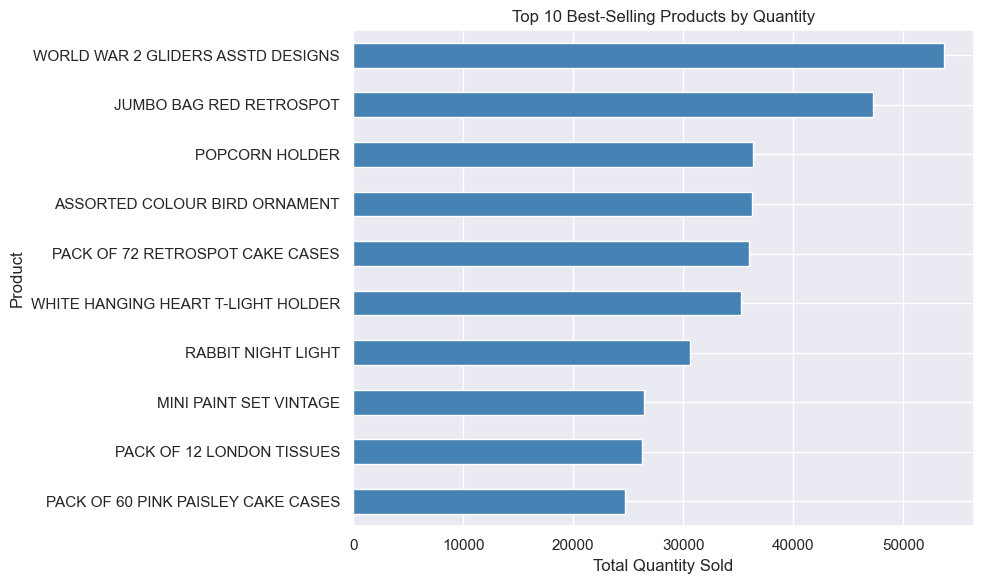

In [297]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

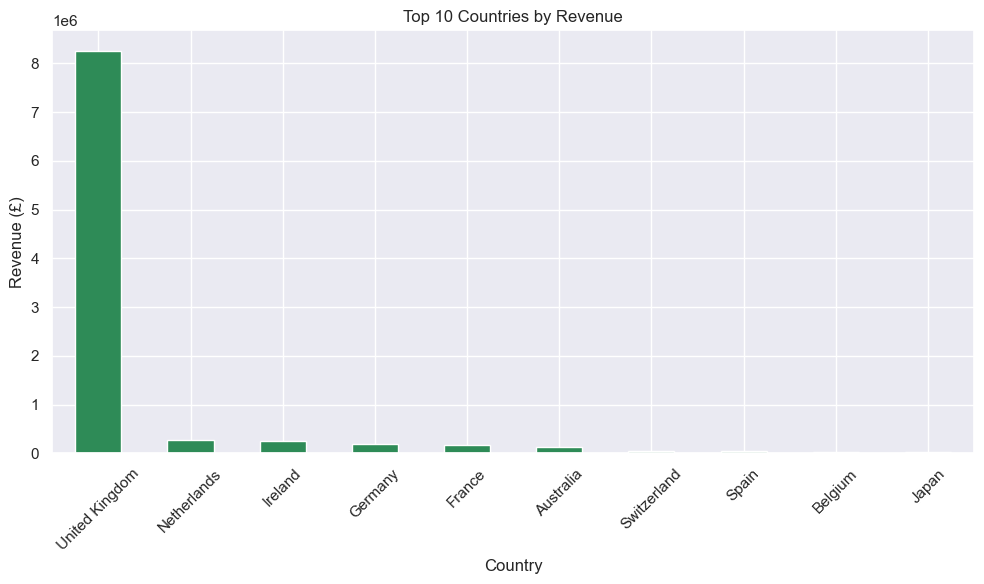

In [298]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='seagreen')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

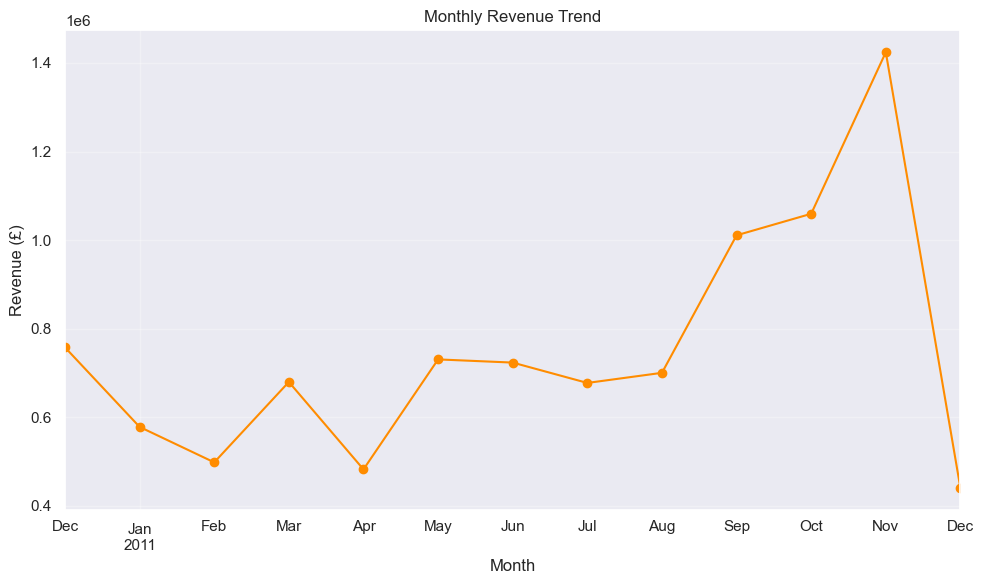

In [299]:
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

plt.figure(figsize=(10,6))
monthly_revenue.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

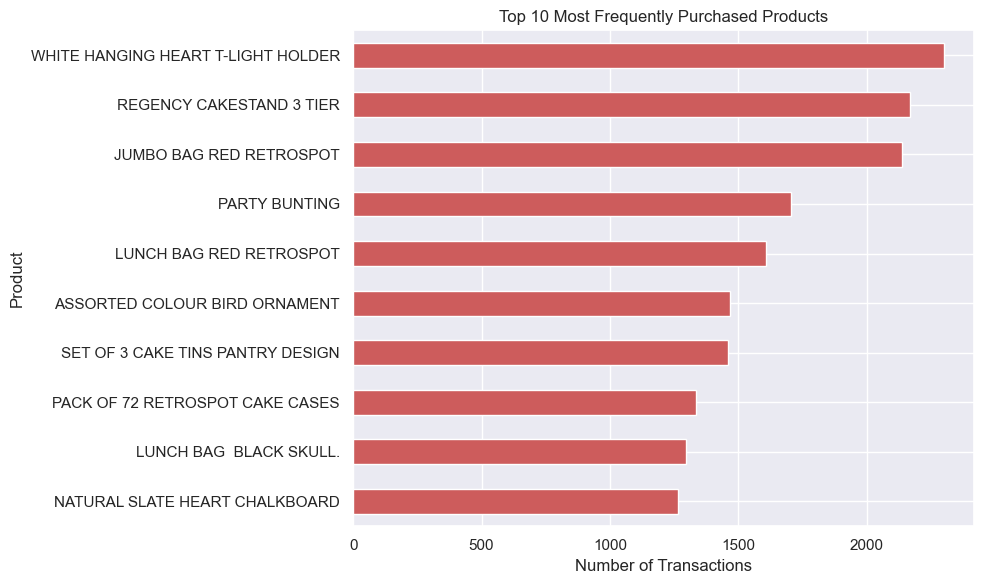

In [300]:
most_purchased = df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
most_purchased.plot(kind='barh', color='indianred')
plt.title('Top 10 Most Frequently Purchased Products')
plt.xlabel('Number of Transactions')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

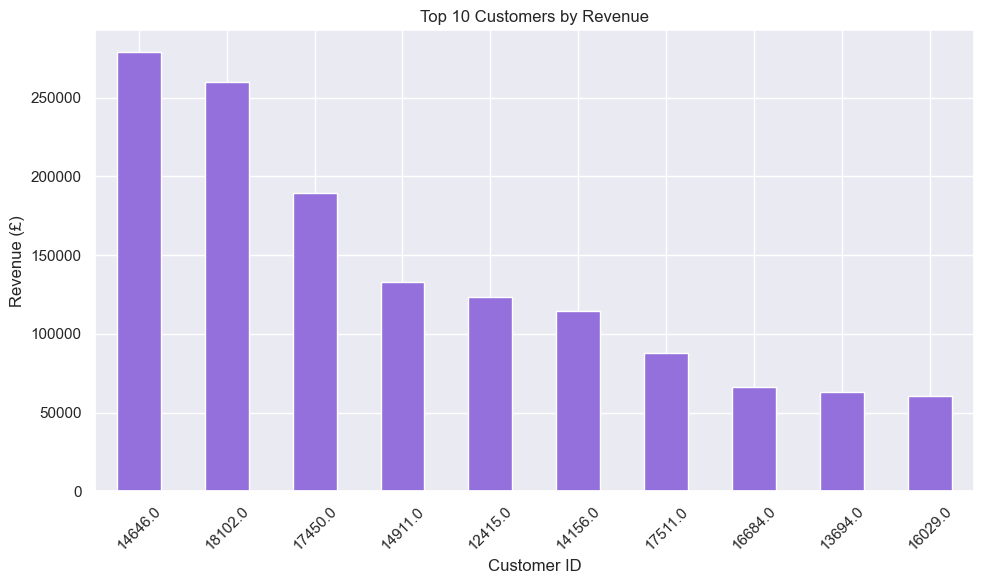

In [301]:
top_customers = df_customers.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_customers.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualisation Findings

**Top-selling products by quantity:** WORLD WAR 2 GLIDERS ASSTD DESIGNS clearly leads the chart, well ahead of the next closest product, suggesting either strong demand or a large bulk order skewing the total.

**Revenue by country:** United Kingdom towers over every other country, confirming the business is heavily UK-dependent, with the Netherlands and Ireland as distant second and third markets.

**Monthly revenue trend:** The line chart shows a clear upward climb from September to November, peaking sharply in November, before a steep drop in December, pointing to strong seasonal, likely holiday-driven, demand.

**Most frequently purchased products:** WHITE HANGING HEART T-LIGHT HOLDER tops this chart, differing from the top seller by quantity, showing it is bought often in smaller amounts rather than in bulk.

**Top customers by revenue:** A small group of customers, led by Customer 14646, account for a disproportionately large share of revenue, highlighting a concentrated high-value customer base worth prioritising for retention.

## Key Insights

**1. Revenue is heavily concentrated in the United Kingdom.**
United Kingdom generated £8.26 million in revenue, dwarfing every other country, including the Netherlands at £283K. This shows the business operates almost entirely within a single domestic market, with international sales representing a small fraction of total revenue. See Revenue by Country chart.

**2. Sales follow a clear seasonal pattern tied to the holiday period.**
Monthly revenue climbs steadily from September through November, peaking at £1.42 million in November, before dropping sharply in December. This strongly suggests the business relies on holiday shopping as a major revenue driver, and should plan inventory and marketing around this window rather than assuming flat demand year round. See Monthly Revenue Trend chart.

**3. A small number of customers drive a disproportionate share of revenue.**
The top 10 customers by revenue, led by Customer 14646 at £278,778, stand well above the typical customer. This points to a concentrated high-value customer base, suggesting the business would benefit from a customer retention or loyalty strategy targeted at this group specifically, rather than treating all customers equally.

**4. Product popularity looks different depending on how it's measured.**
The top-selling product by quantity (WORLD WAR 2 GLIDERS ASSTD DESIGNS) differs from the most frequently purchased product (WHITE HANGING HEART T-LIGHT HOLDER). This shows that high total volume can be driven by a small number of large orders, while genuine repeat popularity is better measured by how often a product is purchased across separate transactions, not just total units sold.

**5. A meaningful share of transactions came from customers without a registered account.**
Nearly 25% of transactions had no CustomerID, most likely representing guest checkouts. This means any customer-level analysis, like the top spender ranking above, only reflects registered customers and likely understates the true scale of the business's total customer base.

---
# Part 2: Netflix Movies & TV Shows Dataset
## Task 1: Dataset Understanding

In [302]:
#Loading the Netflix dataset and creating a copy to use instead of the original
df_netflix_raw = pd.read_csv("netflix_titles.csv")

df_netflix = df_netflix_raw.copy()

#Print upon successful completion
print('Netflix dataset has been loaded')

Netflix dataset has been loaded


In [303]:
#Displaying the first few rows
df_netflix.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [304]:
#Displaying the number of rows and columns
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [305]:
#Displaying the datatypes of each column
df_netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [306]:
#Displaying Numerical Features
df_netflix.select_dtypes(include='number').columns

Index(['release_year'], dtype='object')

In [307]:
#Displaying Categorical Features
df_netflix.select_dtypes(include='object').columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [308]:
#Assessing possible unique identifiers
for col in df_netflix.columns:
    if df_netflix[col].nunique() == len(df_netflix):
        print(col)

show_id
title


## Missing Values

In [309]:
#Identifying columns with missing values
df_netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [310]:
#The percentage of null values in relation to the dataset
(df_netflix.isnull().sum() / len(df_netflix) * 100).round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [311]:
#date_added, rating, and duration are all under 1% missing - safe to drop, 
#negligible impact on the dataset
df_netflix = df_netflix.dropna(subset=['date_added', 'rating', 'duration'])

In [312]:
#Director is missing in 29.91% of rows - too large a portion to drop.
#A missing director does not affect analysis unrelated to director-level insights
#(e.g. content by country, genre trends, ratings distribution).
#Retained in the main dataset; will only be excluded when director-specific
#analysis is needed.

In [313]:
#cast and country are each missing in ~9% of rows. Since these are still valid,
#useful entries for most other analysis (genre, rating, release year trends),
#dropping them would unnecessarily shrink the dataset. Retained in the main
#dataset; will only be excluded when cast or country-specific analysis is needed.

In [314]:
df_netflix.dropna(subset=['country'])['country'].value_counts()

country
United States                             2809
India                                      972
United Kingdom                             418
Japan                                      243
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

In [315]:
df_netflix.shape

(8790, 12)

## Duplicated Values

In [317]:
# Identifying duplicated values
df_netflix.duplicated().sum()

np.int64(0)

In [318]:
#No duplicate rows found. Netflix dataset has no exact duplicate entries.

## Standardisation

In [319]:
df_netflix['date_added'].apply(type).value_counts()

date_added
<class 'str'>    8790
Name: count, dtype: int64

In [320]:
#Converting date_added to datetime, using format='mixed' to handle 
#inconsistent spacing/formatting across entries
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], format='mixed')
df_netflix.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

In [321]:
df_netflix['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [322]:
df_netflix['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [323]:
#Checked 'type' and 'rating' for casing/formatting inconsistencies - both
#already consistent, no cleaning needed.

In [324]:
# Checking for consistency in column names
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [325]:
df_netflix['release_year'].describe()

count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [326]:
#Checking release_year for unusual values (e.g. unrealistic years, future dates)
df_netflix['release_year'].describe()

count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

release_year shows no invalid or unrealistic values. Range spans 1925 to 2021,
consistent with genuine release dates. No cleaning action needed.

In [328]:
#Checking how many rows have multiple countries listed together
df_netflix['country'].str.contains(',', na=False).sum()

np.int64(1320)

In [330]:
#Many rows list multiple co-production countries together (e.g. "Romania, Bulgaria, Hungary"),
#which would fragment country-level analysis. Creating a new column with just the
#first-listed country, treated as the primary country, for cleaner grouping.
#Original 'country' column retained for reference.
df_netflix['primary_country'] = df_netflix['country'].str.split(',').str[0]

In [331]:
df_netflix[['country', 'primary_country']].head(10)

,country,primary_country
0,United States,United States
1,South Africa,South Africa
2,NaN,NaN
3,NaN,NaN
4,India,India
5,NaN,NaN
6,NaN,NaN
7,"United States, Ghana, Burkina Faso, United Kin...",United States
8,United Kingdom,United Kingdom
9,United States,United States


In [332]:
df_netflix['primary_country'].str.startswith(' ').sum()

0

In [333]:
#Exporting the cleaned Netflix dataset
df_netflix.to_csv('Netflix_Cleaned.csv', index=False)

## Data Cleaning Summary (Netflix)

| Issue Found | Action Taken |
|---|---|
| Missing date_added (10 rows), rating (4 rows), duration (3 rows) | Dropped; negligible, safe to remove |
| Missing director (2,634 rows, 29.91%) | Retained; too large a portion to drop, does not affect analysis unrelated to director |
| Missing cast (825 rows, 9.37%) | Retained; still valid for other analysis |
| Missing country (831 rows, 9.44%) | Retained; still valid for other analysis |
| Duplicate rows | None found |
| date_added stored as text | Converted to datetime, using format='mixed' to handle inconsistent spacing |
| type / rating casing | Checked, already consistent, no changes needed |
| Column names | Checked, already consistent, no changes needed |
| release_year | Checked, no invalid values, range 1925 to 2021 |
| Multi-country entries (1,320 rows) | Created primary_country column using first-listed country, for cleaner country-level grouping. Original country column retained |

Final cleaned dataset: 8,790 rows x 13 columns (from an original 8,807 rows x 12 columns)

## Exploratory Data Analysis

In [335]:
#Movies vs TV Shows distribution
df_netflix['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [336]:
#Content added by year
df_netflix['date_added'].dt.year.value_counts().sort_index()

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [337]:
#Top content-producing countries
df_netflix['primary_country'].value_counts().head(10)

primary_country
United States     3202
India             1008
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Australia          115
Name: count, dtype: int64

In [338]:
#Most common ratings
df_netflix['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

In [339]:
#Most common genres/categories
#listed_in contains multiple genres per row, separated by commas
#Splitting and counting each genre individually for an accurate breakdown
df_netflix['listed_in'].str.split(', ').explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

**Movies vs TV Shows:** Movies (6,126) outnumber TV Shows (2,664) by more than 2 to 1, showing the catalogue is film-heavy.

**Content added by year:** Additions grew steadily from 2008, peaking in 2019 at 2,016 titles, before slightly declining in 2020 and 2021.

**Top content-producing countries:** United States leads by a wide margin (3,202 titles), followed by India (1,008) and United Kingdom (627), showing heavy US concentration in the catalogue.

**Most common ratings:** TV-MA (3,205) is the most common rating, followed by TV-14 (2,157), indicating the catalogue skews toward mature audiences rather than family content.

**Most common genres:** International Movies (2,752) and Dramas (2,426) are the most frequent categories, reflecting a strong international and drama-heavy content mix.

## Data Visualisations

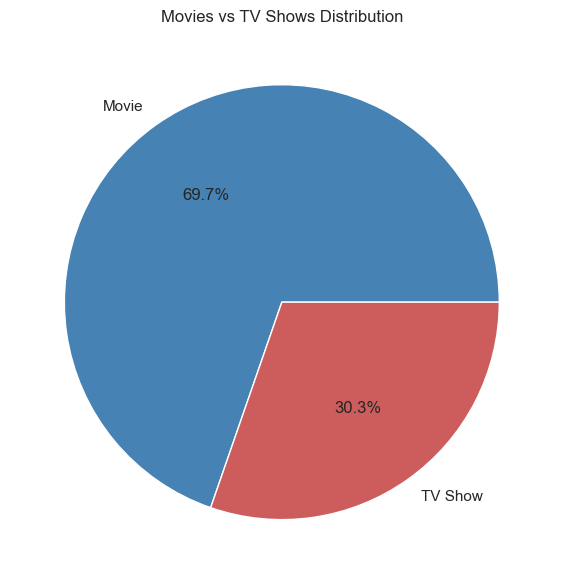

In [340]:
type_counts = df_netflix['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['steelblue', 'indianred'])
plt.title('Movies vs TV Shows Distribution')
plt.tight_layout()
plt.show()

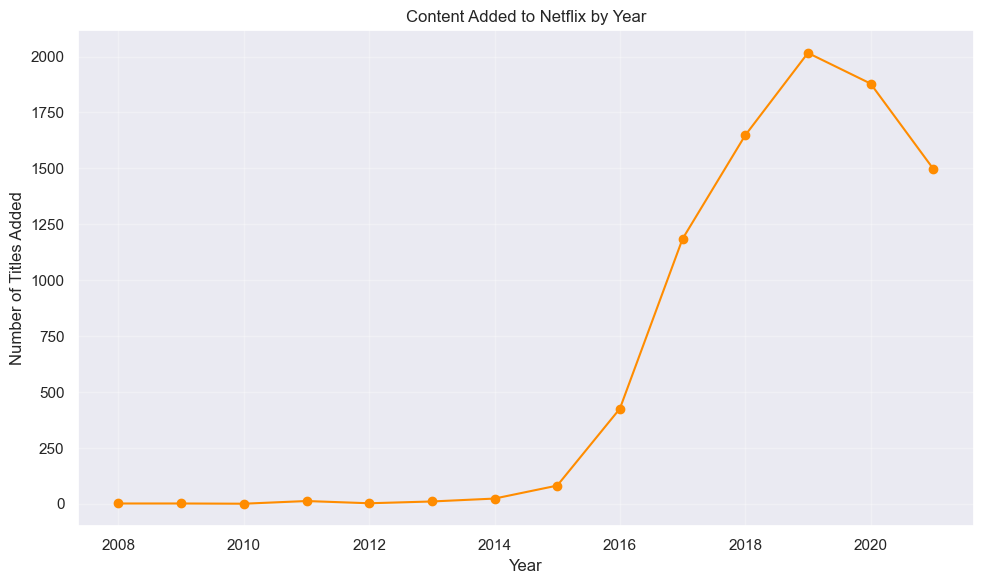

In [341]:
yearly_additions = df_netflix['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,6))
yearly_additions.plot(kind='line', marker='o', color='darkorange')
plt.title('Content Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

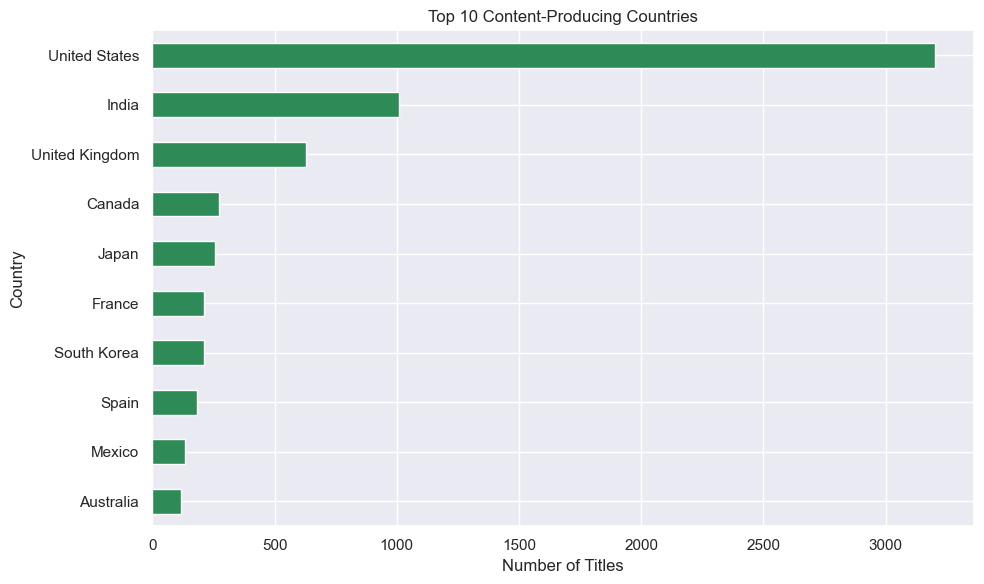

In [342]:
top_countries_netflix = df_netflix['primary_country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries_netflix.plot(kind='barh', color='seagreen')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

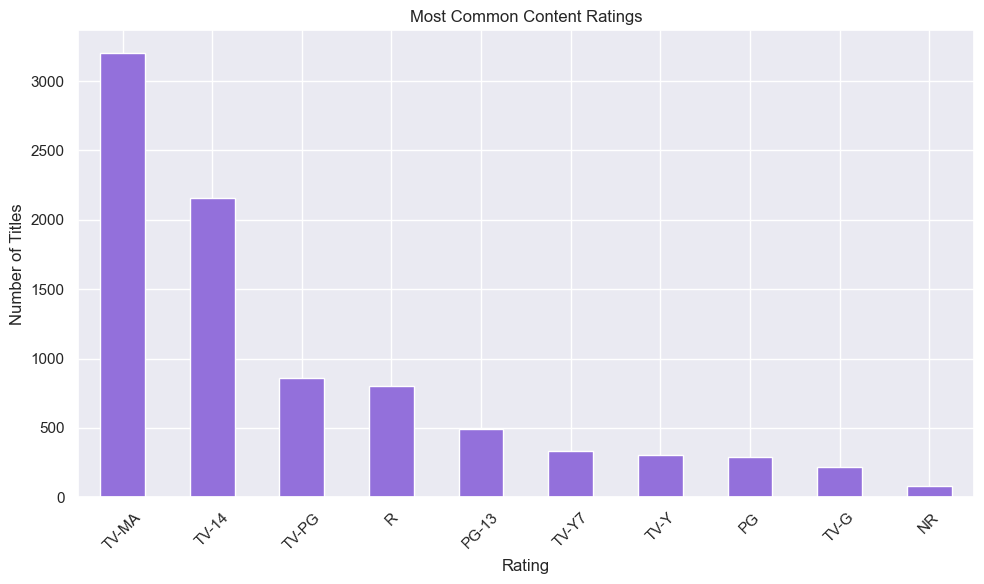

In [343]:
rating_counts = df_netflix['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar', color='mediumpurple')
plt.title('Most Common Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

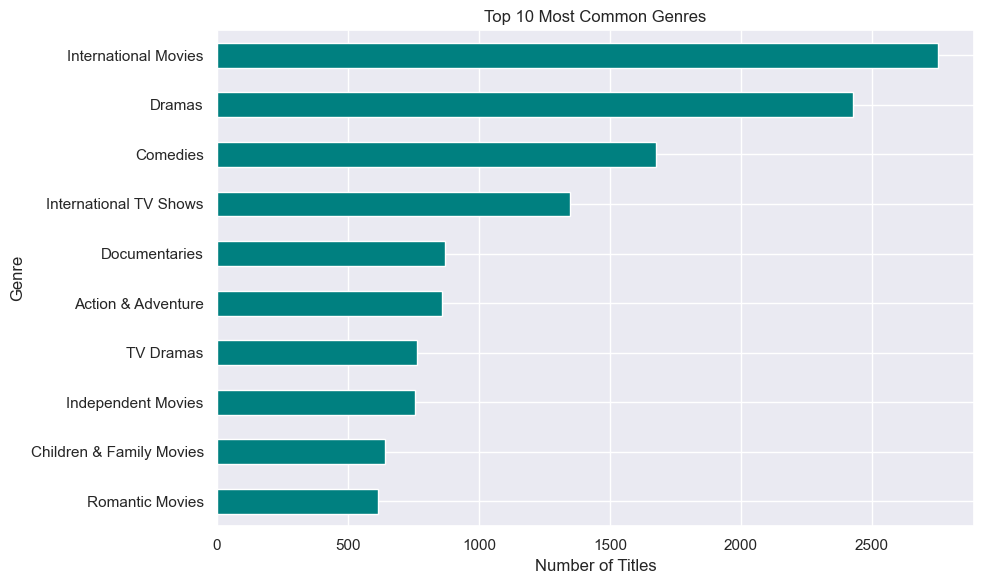

In [344]:
genre_counts = df_netflix['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,6))
genre_counts.plot(kind='barh', color='teal')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Insights

**1. Netflix's catalogue is film-heavy, but not overwhelmingly so.**
Movies make up 6,126 titles compared to 2,664 TV Shows, a ratio of just over 2 to 1. This suggests Netflix still treats TV Shows as a substantial, deliberate part of its catalogue rather than a minor addition, likely due to their higher engagement/retention value despite being more expensive to produce per title. See Movies vs TV Shows chart.

**2. Netflix's catalogue expansion was not gradual, it was explosive from 2016 onward.**
Content additions stayed under 100 titles per year until 2015, then jumped to 426 in 2016 and continued climbing to a peak of 2,016 titles in 2019. This timing lines up with Netflix's well-known global expansion push and increased investment in original content during this period. The slight decline in 2020-2021 is worth further investigation, it may reflect production slowdowns during that time. See Content Added by Year chart.

**3. The catalogue is heavily US-centric, despite Netflix's global reach.**
United States-produced content accounts for 3,202 titles, over 3 times more than the next highest country, India, at 1,008. Given Netflix operates in nearly every country worldwide, this imbalance suggests content acquisition and production have historically been concentrated in the US market, with international content still a growing rather than dominant share. See Top Content-Producing Countries chart.

**4. The catalogue skews toward mature audiences rather than family viewing.**
TV-MA is the single most common rating (3,205 titles), nearly 1.5 times more common than the next rating, TV-14 (2,157). Combined, these two mature-audience ratings account for the majority of the catalogue, while family-friendly ratings like TV-Y and TV-G appear far less often. This positions Netflix's core content strategy around adult and young-adult audiences rather than children's programming. See Most Common Ratings chart.

**5. International content and Dramas define Netflix's genre identity.**
International Movies (2,752) and Dramas (2,426) are the two most frequent genres in the catalogue, ahead of Comedies (1,674) and Documentaries (869). This reinforces the earlier country-level finding, Netflix's catalogue, while US-heavy in production count, is deliberately positioned around international storytelling as a core genre category, not just a byproduct of global operations.